In [1]:
pwd

'D:\\樓上志偉\\2025實測\\notebooks'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sns

pd.options.mode.copy_on_write = True
fm.fontManager.addfont('..\\TaipeiSansTCBeta-Regular.ttf')
plt.rcParams["font.size"] = 14
plt.rcParams['font.family'] = 'Taipei Sans TC Beta'

In [3]:
df_source = pd.read_csv('..\\data\\raw\\偉仁26噸\\B114AS0005_0327_FUEL_CONSUMPTION_HALF_LOAD_1ST.csv', header=2)
# df_source = pd.read_csv('..\\data\\raw\\偉仁26噸\\B114AS0005_0327_FUEL_CONSUMPTION_FULL_LOAD_1ST.csv', header=2)
df_source.head()

,Absolute_time,Relative_time,SYS_TestSequenceNumber,SYS_TestStatus,SYS_TestRunStatus,SYS_TestResultStatus,SYS_TestTime,SYS_TestDistance,SYS_PhaseNo,SYS_PhaseTime,...,TailpipeAmbientRelativeHumidity,TailpipeAmbientAbsoluteHumidity,OBDCalculatedLOADValue,OBDEngineFrictionPercentTorque,OBDEngineCoolantTemp1,OBDDriversDemandEnginePercentTorque,OBDEngineFuelRate_1,OBDEngineFuelRate_2,OBDVehicleFuelRate,VehicleSpeed_Max
0,03/27/2025 09:21:39.6045761,0,9251,1,32,0,925.1,0.023458,1,0.0,...,54.200001,2.548754,22.352942,7,83,0,1.55,0,0,0.020
1,03/27/2025 09:21:40.5945663,1,9261,1,32,0,926.1,0.023488,1,1.0,...,54.200001,2.548754,26.666666,7,83,31,2.30,0,0,0.134
2,03/27/2025 09:21:41.5985794,2,9271,1,32,0,927.1,0.023557,1,2.0,...,54.200001,2.548754,28.627451,8,83,53,3.75,0,0,0.602
3,03/27/2025 09:21:42.5945663,3,9281,1,32,0,928.1,0.024068,1,3.0,...,54.100002,2.544051,69.411766,9,83,49,11.80,0,0,3.288
4,03/27/2025 09:21:43.5945663,4,9291,1,32,0,929.1,0.025264,1,4.0,...,54.100002,2.544051,74.509804,10,83,38,20.60,0,0,5.707


In [4]:
df_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5556 entries, 0 to 5555
Data columns (total 66 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Absolute_time                        5556 non-null   object 
 1   Relative_time                        5556 non-null   int64  
 2   SYS_TestSequenceNumber               5556 non-null   int64  
 3   SYS_TestStatus                       5556 non-null   int64  
 4   SYS_TestRunStatus                    5556 non-null   int64  
 5   SYS_TestResultStatus                 5556 non-null   int64  
 6   SYS_TestTime                         5556 non-null   float64
 7   SYS_TestDistance                     5556 non-null   float64
 8   SYS_PhaseNo                          5556 non-null   int64  
 9   SYS_PhaseTime                        5556 non-null   float64
 10  SYS_TotalPhaseTime                   5556 non-null   float64
 11  GPS_GPSStatus                 

In [5]:
df_source['GPS_GPSNumberOfSatellite'].value_counts()

GPS_GPSNumberOfSatellite
9     2142
10    2059
8      515
11     457
12     319
7       55
6        9
Name: count, dtype: int64

In [6]:
df_source['OBD_DPF_Regeneration_Status'].value_counts()

OBD_DPF_Regeneration_Status
0    5556
Name: count, dtype: int64

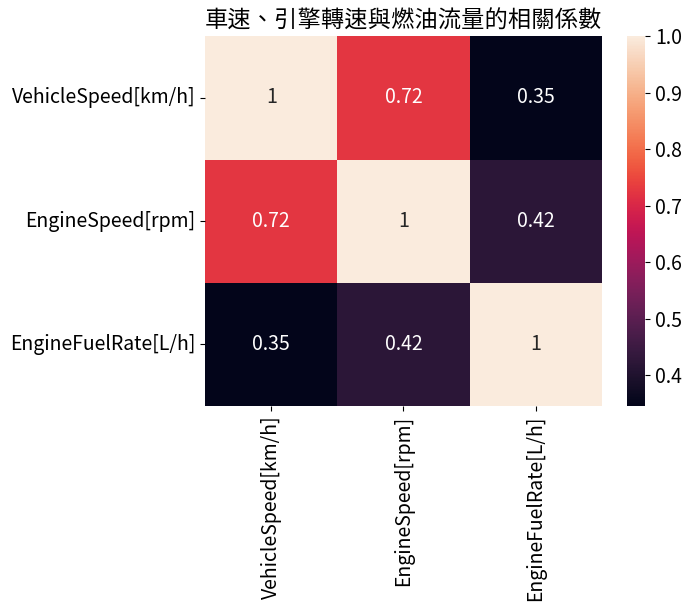

In [7]:
df = df_source[['GPS_VehicleSpeed', 'OBD_EngineSpeed', 'OBD_EngineFuelRate']]
df.columns = ['VehicleSpeed[km/h]', 'EngineSpeed[rpm]', 'EngineFuelRate[L/h]']

sns.heatmap(df.corr(), annot=True)
plt.title("車速、引擎轉速與燃油流量的相關係數")
plt.show()

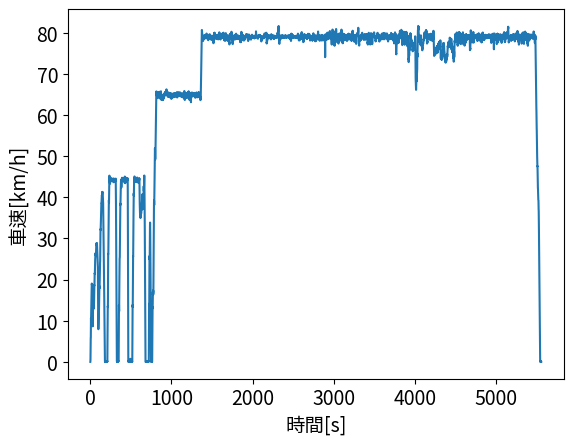

In [8]:
df['time[s]'] = [i for i in range(1, len(df)+1)]

fig = plt.figure() 
plt.plot(df['time[s]'], df['VehicleSpeed[km/h]']) 
plt.xlabel('時間[s]')
plt.ylabel('車速[km/h]')
plt.show()

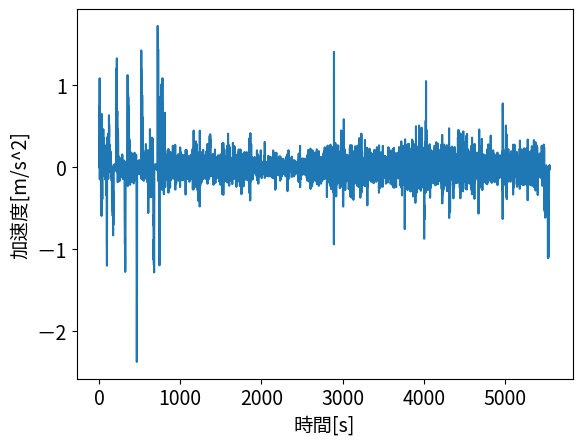

In [9]:
df['acc[m/s^2]'] = 0.
for i in range(1,len(df)):
    df.loc[i, 'acc[m/s^2]'] = (df.loc[i,'VehicleSpeed[km/h]'] - df.loc[i-1,'VehicleSpeed[km/h]']) / 3.6 # 逐秒資料

fig = plt.figure() 
plt.plot(df['time[s]'], df['acc[m/s^2]']) 
plt.xlabel('時間[s]')
plt.ylabel('加速度[m/s^2]')
plt.show()

In [10]:
df.describe()

,VehicleSpeed[km/h],EngineSpeed[rpm],EngineFuelRate[L/h],time[s],acc[m/s^2]
count,5556.000000,5556.000000,5.556000e+03,5556.000000,5556.000000
mean,69.047832,1151.460583,1.783716e+01,2778.500000,0.000002
std,20.093874,161.634486,1.149676e+01,1604.023379,0.196436
min,0.004000,441.500000,-4.440000e-16,1.000000,-2.378611
25%,65.380003,1169.750000,9.100000e+00,1389.750000,-0.066388
50%,78.629997,1211.250000,1.790000e+01,2778.500000,0.000555
75%,79.087248,1217.250000,2.381250e+01,4167.250000,0.067848
max,81.638000,1938.500000,7.350000e+01,5556.000000,1.724445


In [11]:
df.groupby(pd.cut(df['acc[m/s^2]'],
                  bins=[-3,-2.5,-2,-1.5,-1,-0.5,0,0.5,1,1.5,2,2.5,3]),
           observed=False).agg(['count', 'mean'])['EngineFuelRate[L/h]']

,count,mean
acc[m/s^2],,
"(-3.0, -2.5]",0,NaN
"(-2.5, -2.0]",2,0.000000
"(-2.0, -1.5]",2,1.200000
"(-1.5, -1.0]",18,1.872222
"(-1.0, -0.5]",58,2.636207
"(-0.5, 0.0]",2684,16.210637
"(0.0, 0.5]",2716,19.454842
"(0.5, 1.0]",57,33.292105
"(1.0, 1.5]",18,35.380555


In [12]:
# 觀察車速接近0時的燃油流量，中位數相同(500 rpm, 1.8 L/h)
print(df[df['VehicleSpeed[km/h]']<=0.5][['EngineSpeed[rpm]', 'EngineFuelRate[L/h]']].describe())
print()
print(df[df['VehicleSpeed[km/h]']<=1][['EngineSpeed[rpm]', 'EngineFuelRate[L/h]']].describe())
print()
print(df[df['VehicleSpeed[km/h]']<=1.6][['EngineSpeed[rpm]', 'EngineFuelRate[L/h]']].describe())
print()
print(df[df['VehicleSpeed[km/h]']<=2.5][['EngineSpeed[rpm]', 'EngineFuelRate[L/h]']].describe())

       EngineSpeed[rpm]  EngineFuelRate[L/h]
count        175.000000           175.000000
mean         502.040000             1.771714
std           13.371455             0.662794
min          490.750000             0.200000
25%          499.500000             1.550000
50%          500.000000             1.750000
75%          500.500000             1.800000
max          635.500000             8.400000

       EngineSpeed[rpm]  EngineFuelRate[L/h]
count        178.000000           178.000000
mean         502.827247             1.782303
std           17.036145             0.673748
min          490.750000             0.200000
25%          499.500000             1.550000
50%          500.000000             1.750000
75%          500.500000             1.800000
max          644.750000             8.400000

       EngineSpeed[rpm]  EngineFuelRate[L/h]
count        179.000000           179.000000
mean         502.877095             1.780168
std           17.001309             0.672460
min     

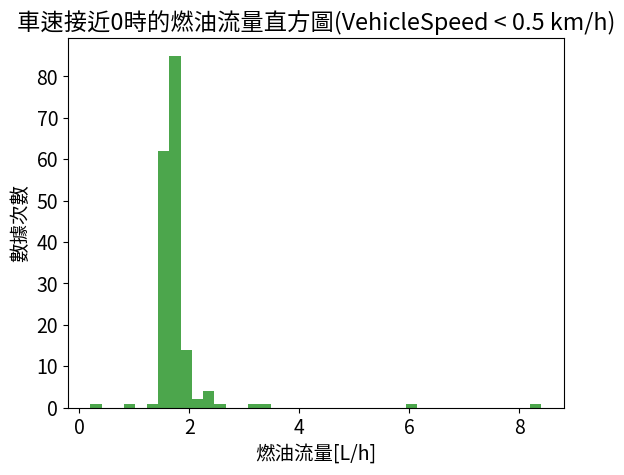

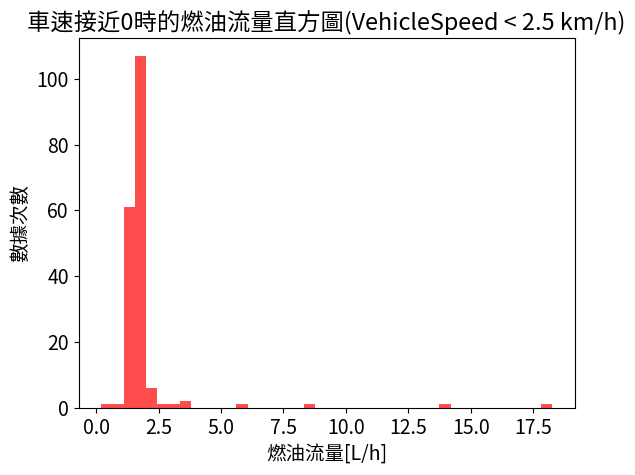

In [13]:
fig = plt.figure() 
plt.hist(df[df['VehicleSpeed[km/h]']<=0.5]['EngineFuelRate[L/h]'], bins=40, alpha=0.7, color='g')
plt.title("車速接近0時的燃油流量直方圖(VehicleSpeed < 0.5 km/h)")
plt.xlabel('燃油流量[L/h]')
plt.ylabel('數據次數')
plt.show()

fig = plt.figure() 
plt.hist(df[df['VehicleSpeed[km/h]']<=2.5]['EngineFuelRate[L/h]'], bins=40, alpha=0.7, color='r')
plt.title("車速接近0時的燃油流量直方圖(VehicleSpeed < 2.5 km/h)")
plt.xlabel('燃油流量[L/h]')
plt.ylabel('數據次數')
plt.show() 

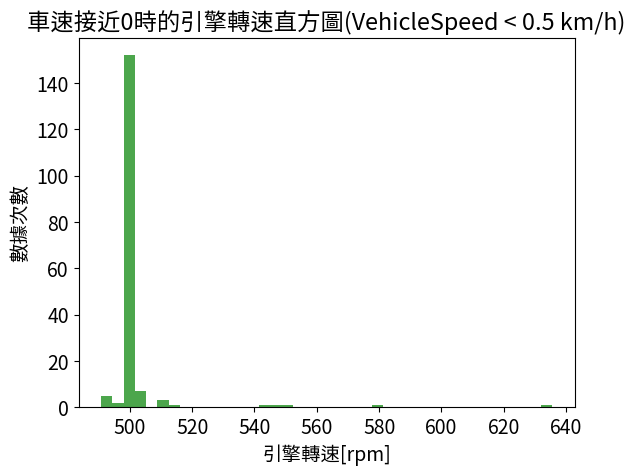

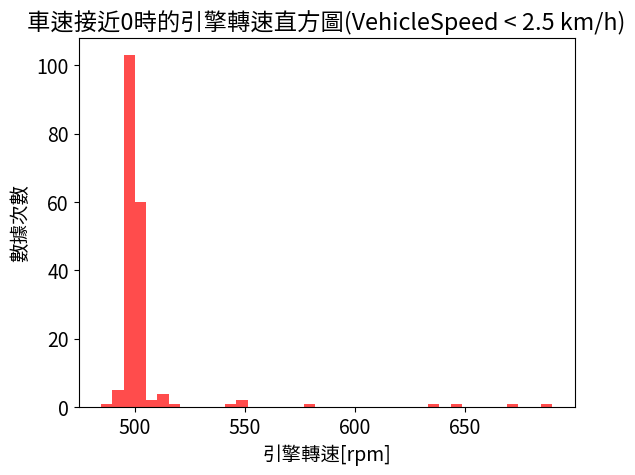

In [14]:
fig = plt.figure() 
plt.hist(df[df['VehicleSpeed[km/h]']<=0.5]['EngineSpeed[rpm]'], bins=40, alpha=0.7, color='g')
plt.title("車速接近0時的引擎轉速直方圖(VehicleSpeed < 0.5 km/h)")
plt.xlabel('引擎轉速[rpm]')
plt.ylabel('數據次數')
plt.show()

fig = plt.figure() 
plt.hist(df[df['VehicleSpeed[km/h]']<=2.5]['EngineSpeed[rpm]'], bins=40, alpha=0.7, color='r')
plt.title("車速接近0時的引擎轉速直方圖(VehicleSpeed < 2.5 km/h)")
plt.xlabel('引擎轉速[rpm]')
plt.ylabel('數據次數')
plt.show()

##### **車輛怠速的燃油流量以車速接近0時的燃油流量中位數為代表**
##### **車速分組的燃油流量以平均數為代表，但車速接近0的分組(間隔大小取一半值)以中位數為代表**

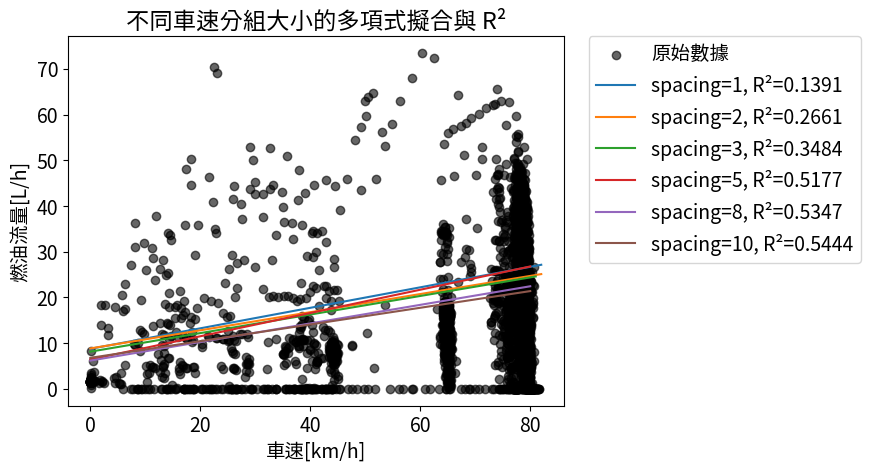

In [15]:
from sklearn.metrics import r2_score

spacing = [1, 2, 3, 5, 8, 10] # 車速分組的間隔大小
r2_scores = {}

plt.scatter(df['VehicleSpeed[km/h]'], df['EngineFuelRate[L/h]'], color='black', label="原始數據", alpha=0.6)
for s in spacing:
    bins = np.arange(s/2, 90, s)
    dfG = df.groupby(pd.cut(df['VehicleSpeed[km/h]'], bins=bins), observed=False).agg(['count', 'mean'])['EngineFuelRate[L/h]'] # observed=True: 只會在結果中包含在數據中實際出現的分類
    dfG['車速[km/h]'] = np.arange(s, 90-s/2, s)
    dfG.columns = ['數據數量', '平均燃油流量[L/h]', '車速[km/h]']
    dfG = dfG.dropna()
    dfG.loc[-1] = [len(df[df['VehicleSpeed[km/h]']<=s/2]),
                   df[df['VehicleSpeed[km/h]']<=s/2]['EngineFuelRate[L/h]'].median(),
                   0]
    dfG = dfG.sort_values(by='車速[km/h]').reset_index(drop=True)

    p = np.polynomial.Polynomial.fit(dfG['車速[km/h]'], dfG['平均燃油流量[L/h]'], deg=1)
    y_fit = p(dfG['車速[km/h]'])
    r2 = r2_score(dfG['平均燃油流量[L/h]'], y_fit)
    r2_scores[s] = r2
    
    plt.plot(dfG['車速[km/h]'], y_fit, label=f"spacing={s}, R²={r2:.4f}")


plt.xlabel("車速[km/h]")
plt.ylabel("燃油流量[L/h]")
plt.legend(bbox_to_anchor=(1.05, 1),
           loc='upper left',
           borderaxespad=0.)
plt.title("不同車速分組大小的多項式擬合與 R²")
plt.show()

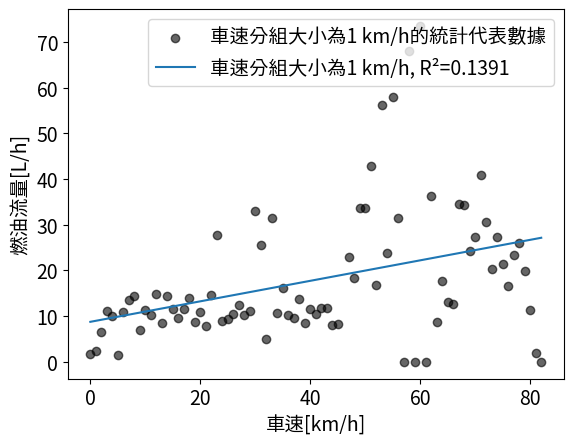

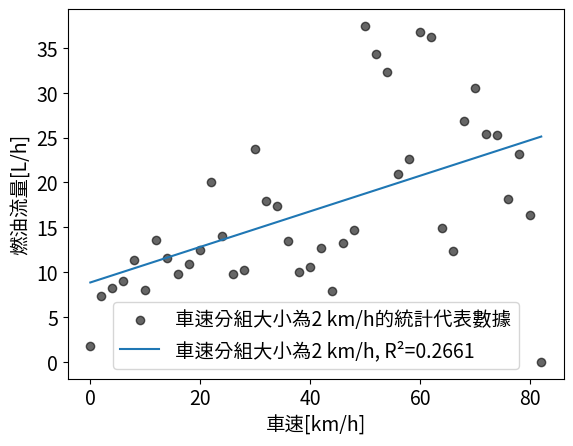

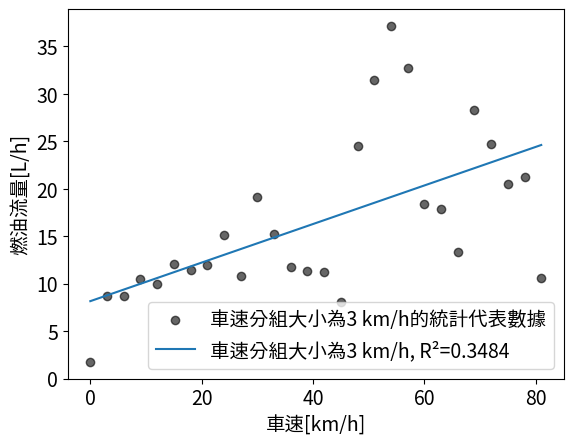

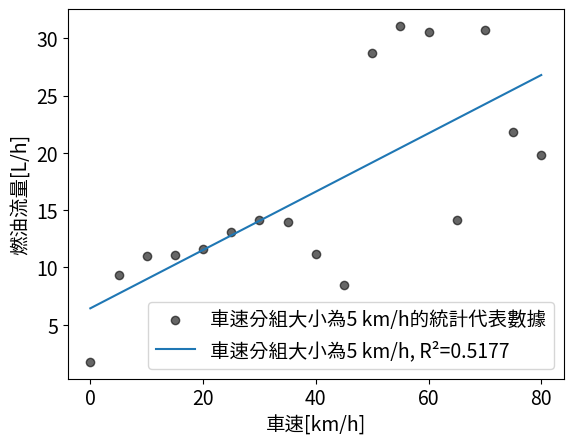

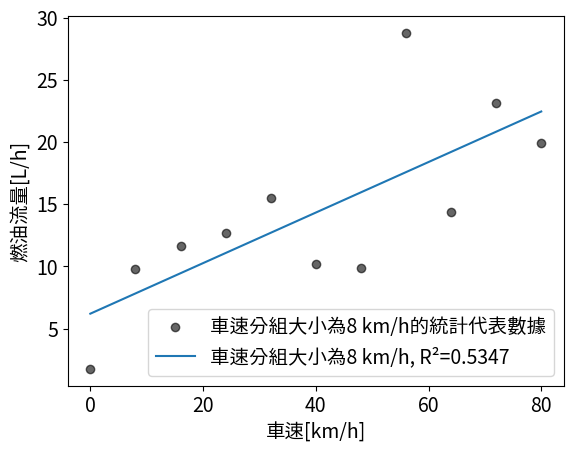

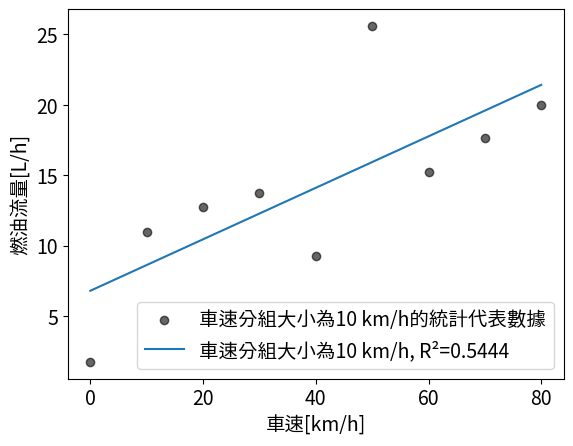

In [16]:
spacing = [1, 2, 3, 5, 8, 10]
r2_scores = {}

for s in spacing:
    bins = np.arange(s/2, 90, s)
    dfG = df.groupby(pd.cut(df['VehicleSpeed[km/h]'], bins=bins), observed=False).agg(['count', 'mean'])['EngineFuelRate[L/h]'] # observed=True: 只會在結果中包含在數據中實際出現的分類
    dfG['車速[km/h]'] = np.arange(s, 90-s/2, s)
    dfG.columns = ['數據數量', '平均燃油流量[L/h]', '車速[km/h]']
    dfG = dfG.dropna()
    dfG.loc[-1] = [len(df[df['VehicleSpeed[km/h]']<=s/2]),
               df[df['VehicleSpeed[km/h]']<=s/2]['EngineFuelRate[L/h]'].median(),
               0]
    dfG = dfG.sort_values(by='車速[km/h]').reset_index(drop=True)

    p = np.polynomial.Polynomial.fit(dfG['車速[km/h]'], dfG['平均燃油流量[L/h]'], deg=1)
    y_fit = p(dfG['車速[km/h]'])
    r2 = r2_score(dfG['平均燃油流量[L/h]'], y_fit)
    r2_scores[s] = r2

    plt.scatter(dfG['車速[km/h]'], dfG['平均燃油流量[L/h]'], color='black', label=f"車速分組大小為{s} km/h的統計代表數據", alpha=0.6)
    plt.plot(dfG['車速[km/h]'], y_fit, label=f"車速分組大小為{s} km/h, R²={r2:.4f}")

    plt.xlabel("車速[km/h]")
    plt.ylabel("燃油流量[L/h]")
    plt.legend()
    plt.show()

##### **參考台灣空氣污染物排放量清冊(Taiwan Emission Data System, TEDS)線源排放係數，車速分組的大小選擇5 km/h**

In [17]:
# # 使用經過處理的資料建模
# from sklearn.metrics import r2_score

# # df = pd.read_csv('..\\data\\processed\\B114AS0005_0327_FUEL_CONSUMPTION_HALF_LOAD_1ST_processed.csv')
# df = pd.read_csv('..\\data\\processed\\B114AS0005_0327_FUEL_CONSUMPTION_FULL_LOAD_1ST_processed.csv')
# df

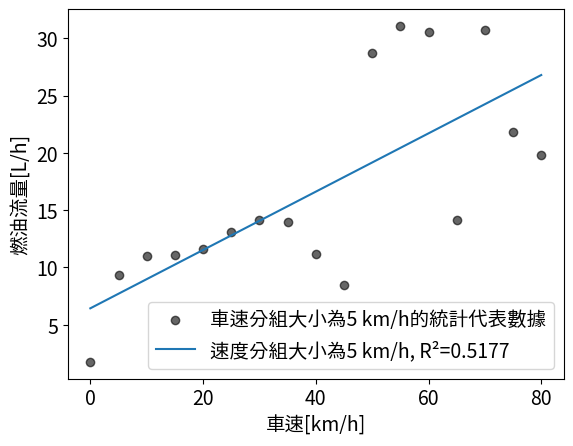

In [18]:
s = 5

bins = np.arange(s/2, 90, s)
dfG = df.groupby(pd.cut(df['VehicleSpeed[km/h]'], bins=bins), observed=False).agg(['count', 'mean'])['EngineFuelRate[L/h]'] # observed=True: 只會在結果中包含在數據中實際出現的分類
dfG['車速[km/h]'] = np.arange(s, 90-s/2, s)
dfG.columns = ['數據數量', '平均燃油流量[L/h]', '車速[km/h]']
dfG = dfG.dropna()
dfG.loc[-1] = [len(df[df['VehicleSpeed[km/h]']<=s/2]),
           df[df['VehicleSpeed[km/h]']<=s/2]['EngineFuelRate[L/h]'].median(),
           0]
dfG = dfG.sort_values(by='車速[km/h]').reset_index(drop=True)

# p = np.polynomial.Polynomial.fit(dfG['車速[km/h]'], dfG['平均燃油流量[L/h]'], deg=1)
p = np.polyfit(dfG['車速[km/h]'], dfG['平均燃油流量[L/h]'], deg=1)
# y_fit = p(dfG['車速[km/h]'])
y_fit = np.poly1d(p)(dfG['車速[km/h]'])
r2 = r2_score(dfG['平均燃油流量[L/h]'], y_fit)

plt.scatter(dfG['車速[km/h]'], dfG['平均燃油流量[L/h]'], color='black', label=f"車速分組大小為{s} km/h的統計代表數據", alpha=0.6)
plt.plot(dfG['車速[km/h]'], y_fit, label=f"速度分組大小為{s} km/h, R²={r2:.4f}")

plt.xlabel("車速[km/h]")
plt.ylabel("燃油流量[L/h]")
plt.legend()
plt.show()

In [19]:
dfG.to_csv(f'..//models//model_1_spacing_{s}km_HALF_LOAD.csv', encoding= 'utf-8-sig', index=False)
# dfG.to_csv(f'..//models//model_1_spacing_{s}km_FULL_LOAD.csv', encoding= 'utf-8-sig', index=False)
# dfG.to_csv(f'..//models//model_1_spacing_{s}km_HALF_LOAD_processed.csv', encoding= 'utf-8-sig', index=False)
# dfG.to_csv(f'..//models//model_1_spacing_{s}km_FULL_LOAD_processed.csv', encoding= 'utf-8-sig', index=False)

In [20]:
np.save(f'..//models//model_1_spacing_{s}km_HALF_LOAD.npy', p)
# np.save(f'..//models//model_1_spacing_{s}km_FULL_LOAD.npy', p)
# np.save(f'..//models//model_1_spacing_{s}km_HALF_LOAD_processed.npy', p)
# np.save(f'..//models//model_1_spacing_{s}km_FULL_LOAD_processed.npy', p)